In [1]:
from google.colab import files
import pandas as pd
import io

# 컴퓨터에서 CSV 파일 선택
uploaded = files.upload()

# 업로드한 파일 읽기
file_name = next(iter(uploaded))
data = pd.read_csv(
    io.BytesIO(uploaded[file_name]),
    encoding="utf-8-sig"
)

# 데이터 개수와 열 이름 확인
print("데이터 개수:", len(data))
print("열 이름:", data.columns.tolist())

# 처음 5개 데이터 표시
display(data.head())

Saving SeoulBikeData_1000_3inputs.csv to SeoulBikeData_1000_3inputs.csv
데이터 개수: 1000
열 이름: ['Temperature(°C)', 'Humidity(%)', 'Wind speed (m/s)', 'Rented Bike Count']


,Temperature(°C),Humidity(%),Wind speed (m/s),Rented Bike Count
0,27.2,69,1.8,1728
1,32.6,51,2.1,822
2,34.0,50,1.2,658
3,16.9,47,1.4,2716
4,6.4,51,1.0,1083


In [2]:
from sklearn.model_selection import train_test_split

# 입력값: 기온, 습도, 풍속
input_columns = [
    "Temperature(°C)",
    "Humidity(%)",
    "Wind speed (m/s)"
]

X = data[input_columns]

# 예측할 값: 자전거 대여량
y = data["Rented Bike Count"]

# 학습용 80%, 평가용 20%로 나누기
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("학습용 데이터:", len(X_train), "개")
print("평가용 데이터:", len(X_test), "개")
print("입력 항목:", input_columns)

학습용 데이터: 800 개
평가용 데이터: 200 개
입력 항목: ['Temperature(°C)', 'Humidity(%)', 'Wind speed (m/s)']


In [3]:
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import make_pipeline
from sklearn.compose import TransformedTargetRegressor

# 입력값의 단위를 맞추는 표준화 + 인공신경망
neural_network = make_pipeline(
    StandardScaler(),
    MLPRegressor(
        hidden_layer_sizes=(32, 16),
        activation="relu",
        solver="adam",
        max_iter=2000,
        early_stopping=True,
        random_state=42,
        verbose=True
    )
)

# 대여량도 표준화하여 학습하고, 예측 시 원래 단위로 복원
model = TransformedTargetRegressor(
    regressor=neural_network,
    transformer=StandardScaler()
)

# 학습 실행: 가중치와 편향이 자동으로 조정됨
model.fit(X_train, y_train)

# 학습된 인공신경망 꺼내기 — 다음 단계 그래프에 사용
ann = model.regressor_.named_steps["mlpregressor"]

print("\n학습 완료!")
print("학습 반복 횟수:", ann.n_iter_)
print("은닉층 구성:", ann.hidden_layer_sizes)

Iteration 1, loss = 0.72565199
Validation score: -0.488736
Iteration 2, loss = 0.66904280
Validation score: -0.371490
Iteration 3, loss = 0.62130959
Validation score: -0.274582
Iteration 4, loss = 0.58205192
Validation score: -0.191829
Iteration 5, loss = 0.54745506
Validation score: -0.120981
Iteration 6, loss = 0.51933241
Validation score: -0.059040
Iteration 7, loss = 0.49401704
Validation score: -0.003392
Iteration 8, loss = 0.47080319
Validation score: 0.045782
Iteration 9, loss = 0.45089028
Validation score: 0.089350
Iteration 10, loss = 0.43263543
Validation score: 0.128305
Iteration 11, loss = 0.41561057
Validation score: 0.162443
Iteration 12, loss = 0.40084029
Validation score: 0.194263
Iteration 13, loss = 0.38672488
Validation score: 0.223729
Iteration 14, loss = 0.37406239
Validation score: 0.250362
Iteration 15, loss = 0.36200263
Validation score: 0.274887
Iteration 16, loss = 0.35130416
Validation score: 0.298395
Iteration 17, loss = 0.34079867
Validation score: 0.319267

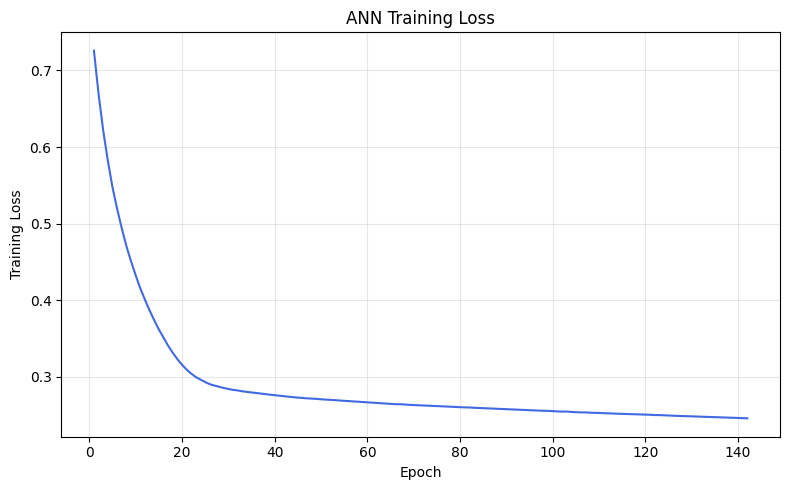

첫 번째 손실값: 0.7257
마지막 손실값: 0.2459


In [4]:
import matplotlib.pyplot as plt

# 매 학습 반복에서 기록한 손실값
loss_history = ann.loss_curve_
epochs = range(1, len(loss_history) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, loss_history, color="royalblue")

plt.title("ANN Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("첫 번째 손실값:", round(loss_history[0], 4))
print("마지막 손실값:", round(loss_history[-1], 4))

평균 절대 오차(MAE): 292.70대
결정계수(R²): 0.5070


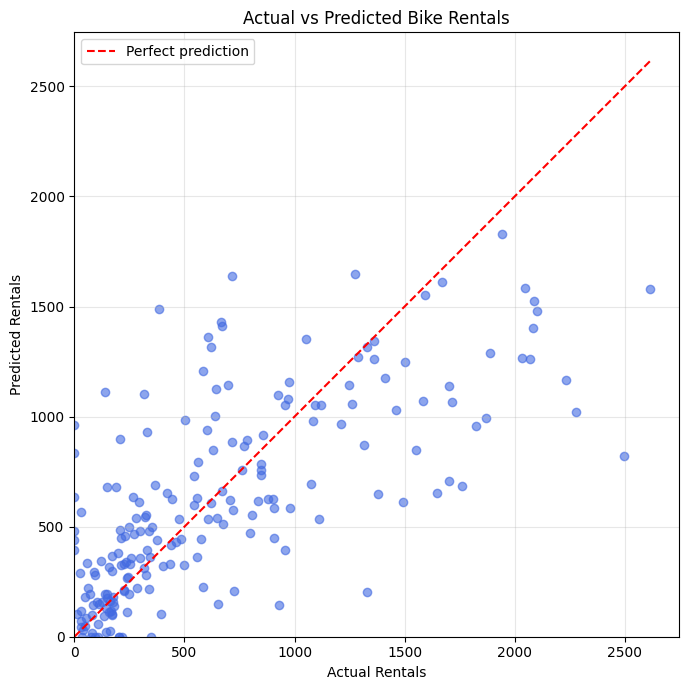

In [5]:
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt

# 평가용 데이터의 대여량 예측
# GitHub 코드와 동일하게 음수 예측값은 0으로 보정
y_pred = model.predict(X_test).clip(min=0)

# 예측 성능 계산
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"평균 절대 오차(MAE): {mae:.2f}대")
print(f"결정계수(R²): {r2:.4f}")

# 실제값과 예측값 비교 그래프
plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_pred, alpha=0.6, color="royalblue")

# 실제값과 예측값이 정확히 일치하는 기준선
upper = max(float(y_test.max()), float(y_pred.max()))
plt.plot(
    [0, upper],
    [0, upper],
    "r--",
    label="Perfect prediction"
)

plt.title("Actual vs Predicted Bike Rentals")
plt.xlabel("Actual Rentals")
plt.ylabel("Predicted Rentals")
plt.xlim(0, upper * 1.05)
plt.ylim(0, upper * 1.05)
plt.gca().set_aspect("equal", adjustable="box")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [6]:
# 예측할 조건 입력
temperature = float(input("기온을 입력하세요 (°C): "))
humidity = float(input("습도를 입력하세요 (%): "))
wind_speed = float(input("풍속을 입력하세요 (m/s): "))

# 학습 데이터와 같은 열 이름 및 순서로 구성
new_data = pd.DataFrame(
    [[temperature, humidity, wind_speed]],
    columns=input_columns
)

# 예측 가능한 입력 범위 확인
within_range = True

for column in input_columns:
    value = new_data.loc[0, column]
    minimum = data[column].min()
    maximum = data[column].max()

    if not minimum <= value <= maximum:
        print(
            f"주의: {column} 입력값이 데이터 범위"
            f"({minimum} ~ {maximum}) 밖입니다."
        )
        within_range = False

if within_range:
    prediction = max(0.0, float(model.predict(new_data)[0]))
    print(f"\n예측 자전거 대여량: 약 {prediction:,.0f}대")
else:
    print("데이터 범위 안의 값으로 다시 실행해 주세요.")

기온을 입력하세요 (°C): 20
습도를 입력하세요 (%): 50
풍속을 입력하세요 (m/s): 1.5

예측 자전거 대여량: 약 1,189대
